<a href="https://colab.research.google.com/github/AdeelAsghar11/deep-learning-playground/blob/main/twitter_sentiment_analyss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
jp797498e_twitter_entity_sentiment_analysis_path = kagglehub.dataset_download('jp797498e/twitter-entity-sentiment-analysis')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

path = os.path.join(dirname)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv
/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv


In [ ]:
# Cell 2 — Load dataset
import pandas as pd

train_df = pd.read_csv(f"{path}/twitter_training.csv", header=None,
                       names=['id', 'entity', 'sentiment', 'text'])
val_df   = pd.read_csv(f"{path}/twitter_validation.csv", header=None,
                       names=['id', 'entity', 'sentiment', 'text'])

df = pd.concat([train_df, val_df], ignore_index=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSentiment classes:", df['sentiment'].unique())
print("\nClass distribution:")
print(df['sentiment'].value_counts())
print("\nSample rows:")
print(df[['sentiment', 'text']].head(5).to_string())

Shape: (75682, 4)

Columns: ['id', 'entity', 'sentiment', 'text']

Sentiment classes: ['Positive' 'Neutral' 'Negative' 'Irrelevant']

Class distribution:
sentiment
Negative      22808
Positive      21109
Neutral       18603
Irrelevant    13162
Name: count, dtype: int64

Sample rows:
  sentiment                                                       text
0  Positive      im getting on borderlands and i will murder you all ,
1  Positive        I am coming to the borders and I will kill you all,
2  Positive         im getting on borderlands and i will kill you all,
3  Positive        im coming on borderlands and i will murder you all,
4  Positive  im getting on borderlands 2 and i will murder you me all,


In [ ]:
# Cell 3 — Clean and balance
from sklearn.utils import resample

# Drop Irrelevant class
df = df[df['sentiment'] != 'Irrelevant'].reset_index(drop=True)

# Drop rows with missing text
df = df.dropna(subset=['text']).reset_index(drop=True)

print("After removing Irrelevant:", df.shape)
print("\nClass distribution:")
print(df['sentiment'].value_counts())

# Undersample to minority class
min_count = df['sentiment'].value_counts().min()
balanced_df = pd.concat([
    resample(df[df['sentiment'] == label],
             replace=False,
             n_samples=min_count,
             random_state=42)
    for label in df['sentiment'].unique()
]).reset_index(drop=True)

print("\nBalanced shape:", balanced_df.shape)
print(balanced_df['sentiment'].value_counts())

# Add text length
balanced_df['text_length'] = balanced_df['text'].apply(lambda x: len(str(x).split()))
print("\nText length stats:")
print(balanced_df['text_length'].describe().round(1))

After removing Irrelevant: (61949, 4)

Class distribution:
sentiment
Negative    22624
Positive    20932
Neutral     18393
Name: count, dtype: int64

Balanced shape: (55179, 4)
sentiment
Positive    18393
Neutral     18393
Negative    18393
Name: count, dtype: int64

Text length stats:
count    55179.0
mean        19.2
std         14.5
min          0.0
25%          8.0
50%         15.0
75%         27.0
max        198.0
Name: text_length, dtype: float64


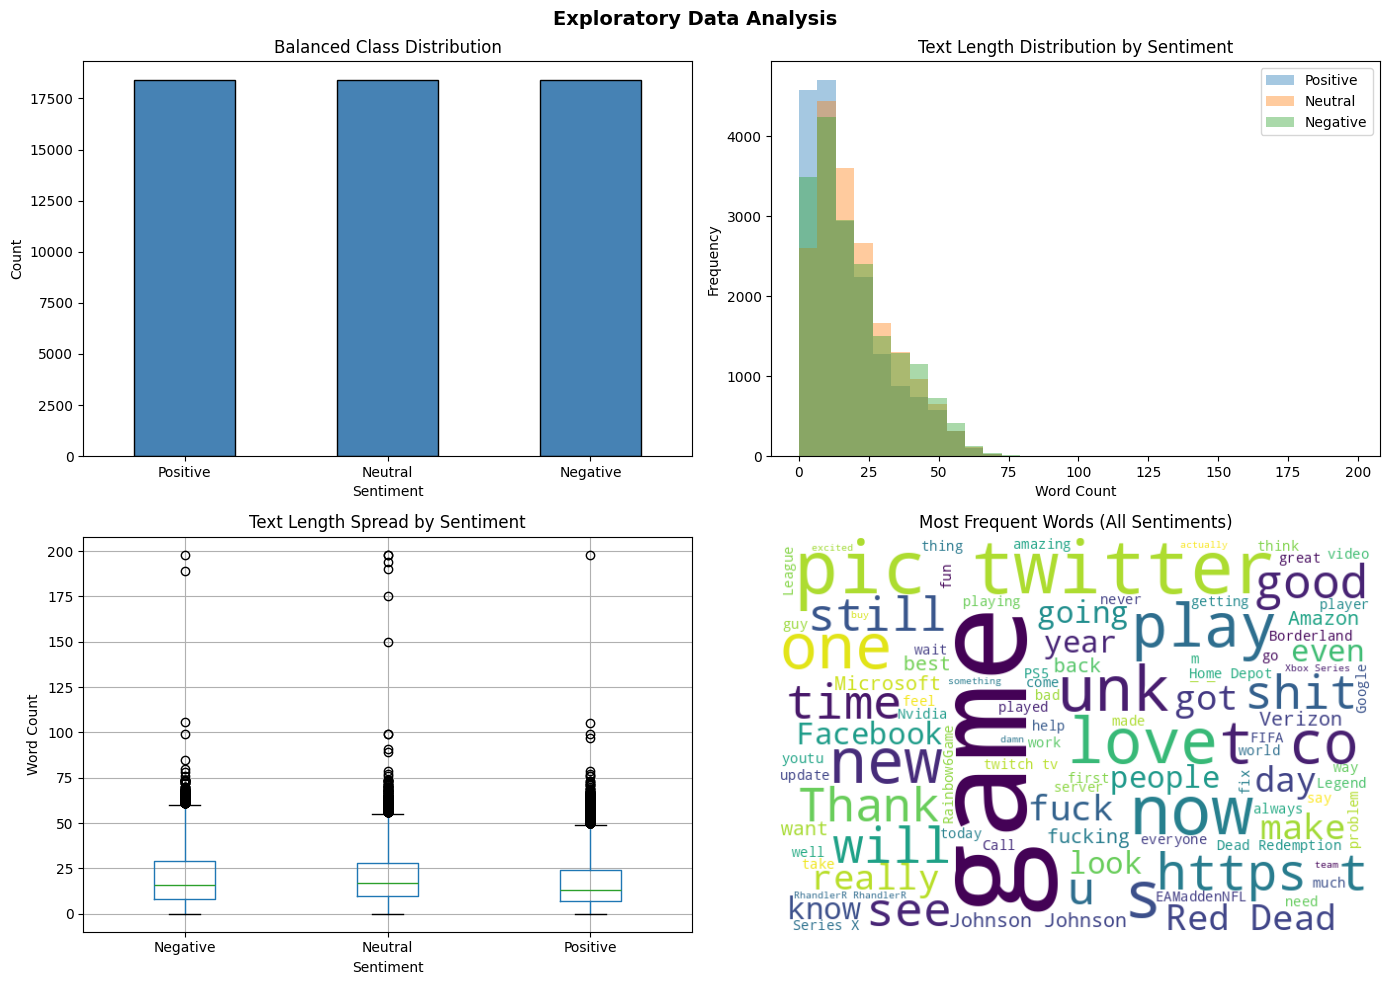

In [ ]:
# Cell 4 — EDA Visualisations
import matplotlib.pyplot as plt
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Balanced class distribution
balanced_df['sentiment'].value_counts().plot(kind='bar', ax=axes[0,0],
                                              color='steelblue', edgecolor='black')
axes[0,0].set_title('Balanced Class Distribution')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Text length distribution per sentiment
for sentiment in balanced_df['sentiment'].unique():
    subset = balanced_df[balanced_df['sentiment'] == sentiment]['text_length']
    axes[0,1].hist(subset, alpha=0.4, label=sentiment, bins=30)
axes[0,1].set_title('Text Length Distribution by Sentiment')
axes[0,1].set_xlabel('Word Count')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# 3. Boxplot of text length per sentiment
balanced_df.boxplot(column='text_length', by='sentiment', ax=axes[1,0])
axes[1,0].set_title('Text Length Spread by Sentiment')
axes[1,0].set_xlabel('Sentiment')
axes[1,0].set_ylabel('Word Count')
plt.sca(axes[1,0])
plt.xticks(rotation=0)

# 4. Word cloud
all_text = ' '.join(balanced_df['text'].astype(str).values)
wc = WordCloud(width=600, height=400, background_color='white',
               max_words=100).generate(all_text)
axes[1,1].imshow(wc, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('Most Frequent Words (All Sentiments)')

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5 — Preprocessing + Split + Baseline
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# --- Clean text ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)       # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

balanced_df['clean_text'] = balanced_df['text'].apply(clean_text)

# --- Encode labels ---
le = LabelEncoder()
balanced_df['label'] = le.fit_transform(balanced_df['sentiment'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# --- Split 80/10/10 ---
X = balanced_df['clean_text']
y = balanced_df['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5,
                                                     random_state=42, stratify=y_temp)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# --- Baseline ---
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("\n--- Baseline (Majority Class) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")

Label mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

Train: 44143 | Val: 5518 | Test: 5518

--- Baseline (Majority Class) ---
Accuracy : 0.3333
F1 (macro): 0.1666


Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Best params: {'clf__C': 10.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.8293

--- Tuned Logistic Regression (Validation) ---
Accuracy : 0.8559
F1 (macro): 0.8561

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86      1839
     Neutral       0.82      0.87      0.84      1839
    Positive       0.87      0.86      0.86      1840

    accuracy                           0.86      5518
   macro avg       0.86      0.86      0.86      5518
weighted avg       0.86      0.86      0.86      5518



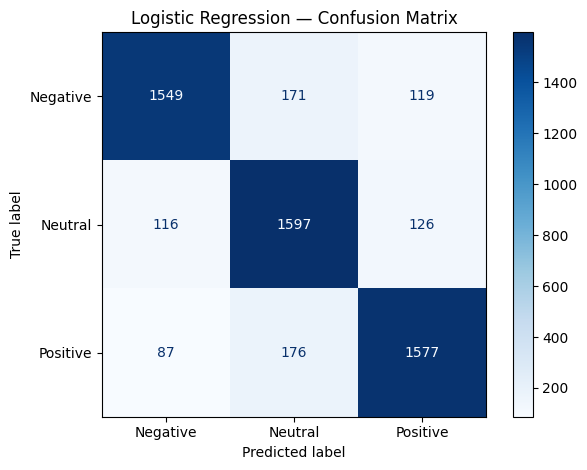

In [ ]:
# Cell 6 — Traditional Model 1: Logistic Regression + Tuning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Pipeline ---
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', LogisticRegression(multi_class='multinomial', solver='lbfgs',
                               max_iter=1000, random_state=42))
])

# --- Tune ---
lr_params = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1.0, 10.0]
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=3,
                       scoring='f1_macro', n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV F1:", round(lr_grid.best_score_, 4))

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_val)

print("\n--- Tuned Logistic Regression (Validation) ---")
print(f"Accuracy : {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_lr, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr, target_names=le.classes_))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_lr),
                       display_labels=le.classes_).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

Accuracy : 0.7519
F1 (macro): 0.7527
              precision    recall  f1-score   support

    Negative       0.80      0.75      0.78      1839
     Neutral       0.68      0.80      0.73      1839
    Positive       0.80      0.71      0.75      1840

    accuracy                           0.75      5518
   macro avg       0.76      0.75      0.75      5518
weighted avg       0.76      0.75      0.75      5518



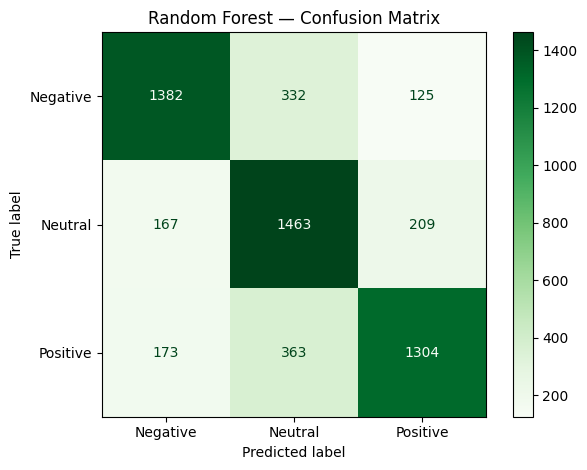

In [ ]:
# After switching to T4 — skip RF grid search, use best params directly
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

best_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=50,
                                   random_state=42, n_jobs=-1))
])
best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_val)
print(f"Accuracy : {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_rf, average='macro'):.4f}")
print(classification_report(y_val, y_pred_rf, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_rf),
                       display_labels=le.classes_).plot(cmap='Greens')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 8 — Traditional Models Test Summary
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_pred_lr_test = best_lr.predict(X_test)
y_pred_rf_test = best_rf.predict(X_test)
y_test_bin     = label_binarize(y_test, classes=range(3))

lr_proba = best_lr.predict_proba(X_test)
rf_proba = best_rf.predict_proba(X_test)

import pandas as pd
results = {
    'Model':    ['Baseline', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, dummy.predict(X_test)), 4),
        round(accuracy_score(y_test, y_pred_lr_test), 4),
        round(accuracy_score(y_test, y_pred_rf_test), 4)
    ],
    'F1 Macro': [
        round(f1_score(y_test, dummy.predict(X_test), average='macro'), 4),
        round(f1_score(y_test, y_pred_lr_test, average='macro'), 4),
        round(f1_score(y_test, y_pred_rf_test, average='macro'), 4)
    ],
    'ROC-AUC': [
        'N/A',
        round(roc_auc_score(y_test_bin, lr_proba, multi_class='ovr'), 4),
        round(roc_auc_score(y_test_bin, rf_proba, multi_class='ovr'), 4)
    ]
}

print(pd.DataFrame(results).to_string(index=False))

              Model  Accuracy  F1 Macro ROC-AUC
           Baseline    0.3333    0.1666     N/A
Logistic Regression    0.8550    0.8552  0.9624
      Random Forest    0.7601    0.7608  0.9188


In [ ]:
# Cell 9 — Deep Learning Setup: Tokenization for BiLSTM
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN   = 50

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer_lstm.texts_to_sequences(X_val),   maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test),  maxlen=MAX_LEN)

print("Train shape:", X_train_seq.shape)

2026-04-22 08:35:13.552190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776846913.776657      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776846913.844063      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776846914.368901      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776846914.368968      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776846914.368973      55 computation_placer.cc:177] computation placer alr

Train shape: (44143, 50)


In [ ]:
# Cell 10 — Deep Learning Model 1: BiLSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM,
                                     Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping

model_bilstm = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_bilstm.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam', metrics=['accuracy'])
model_bilstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_bilstm = model_bilstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1776846941.326432      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776846941.332627      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 87s 224ms/step - accuracy: 0.5386 - loss: 0.9299 - val_accuracy: 0.7744 - val_loss: 0.5623
Epoch 2/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 75s 217ms/step - accuracy: 0.8264 - loss: 0.4510 - val_accuracy: 0.8295 - val_loss: 0.4455
Epoch 3/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 75s 217ms/step - accuracy: 0.8848 - loss: 0.2983 - val_accuracy: 0.8541 - val_loss: 0.3808
Epoch 4/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 74s 214ms/step - accuracy: 0.9143 - loss: 0.2230 - val_accuracy: 0.8695 - val_loss: 0.3603
Epoch 5/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 77s 222ms/step - accuracy: 0.9284 - loss: 0.1836 - val_accuracy: 0.8704 - val_loss: 0.3699
Epoch 6/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 76s 220ms/step - accuracy: 0.9355 - loss: 0.1604 - val_accuracy: 0.8784 - val_loss: 0.3666
Epoch 7/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 76s 219ms/step - accuracy: 0.9424 - loss: 0.1441 - val_accuracy: 0.8788 - val_loss: 0.3658


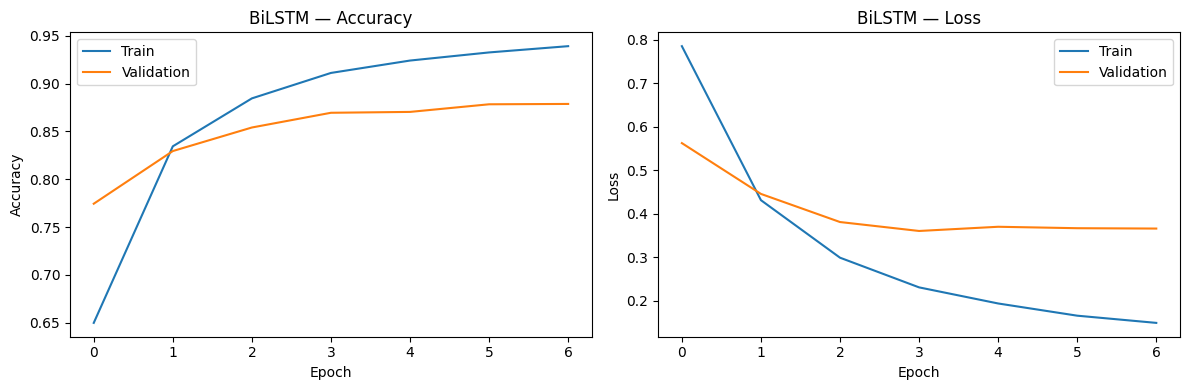

173/173 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step
--- BiLSTM (Test) ---
Accuracy : 0.8679
F1 (macro): 0.8679
ROC-AUC  : 0.9679
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      1839
     Neutral       0.85      0.87      0.86      1840
    Positive       0.87      0.87      0.87      1839

    accuracy                           0.87      5518
   macro avg       0.87      0.87      0.87      5518
weighted avg       0.87      0.87      0.87      5518



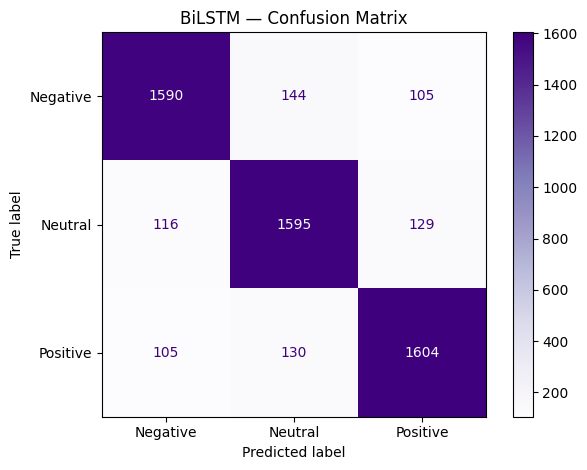

In [ ]:
# Cell 11 — BiLSTM Evaluation + Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_bilstm.history['accuracy'], label='Train')
ax1.plot(history_bilstm.history['val_accuracy'], label='Validation')
ax1.set_title('BiLSTM — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_bilstm.history['loss'], label='Train')
ax2.plot(history_bilstm.history['val_loss'], label='Validation')
ax2.set_title('BiLSTM — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

y_pred_bilstm  = np.argmax(model_bilstm.predict(X_test_seq), axis=1)
y_proba_bilstm = model_bilstm.predict(X_test_seq)

print("--- BiLSTM (Test) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_bilstm):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_bilstm, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_bin, y_proba_bilstm, multi_class='ovr'):.4f}")
print(classification_report(y_test, y_pred_bilstm, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_bilstm),
                       display_labels=le.classes_).plot(cmap='Purples')
plt.title('BiLSTM — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12a — BERT Setup
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import sys

DEVICE     = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
BERT_MODEL = 'bert-base-uncased'
MAX_LEN_B  = 64
BATCH_SIZE = 32
EPOCHS_B   = 4

print("Device:", DEVICE)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True,
                                   max_length=MAX_LEN_B, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}, self.labels[idx]

bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)

train_loader = DataLoader(SentimentDataset(X_train, y_train, bert_tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SentimentDataset(X_val,   y_val,   bert_tokenizer),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(SentimentDataset(X_test,  y_test,  bert_tokenizer),
                          batch_size=BATCH_SIZE)

bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=3)
bert_model.to(DEVICE)

optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader),
    num_training_steps=len(train_loader) * EPOCHS_B
)
print("Setup complete.")

Device: cuda:0


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Setup complete.


In [ ]:
# Cell 12b — BERT Training
for epoch in range(EPOCHS_B):
    bert_model.train()
    total_loss, correct = 0, 0
    for batch, labels in train_loader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        labels  = labels.to(DEVICE)
        outputs = bert_model(**batch, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        correct    += (outputs.logits.argmax(dim=1) == labels).sum().item()

    train_acc = correct / len(X_train)
    print(f"Epoch {epoch+1}/{EPOCHS_B} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f}", flush=True)
    sys.stdout.flush()

Epoch 1/4 | Loss: 0.7988 | Train Acc: 0.6399
Epoch 2/4 | Loss: 0.4401 | Train Acc: 0.8300
Epoch 3/4 | Loss: 0.1992 | Train Acc: 0.9264
Epoch 4/4 | Loss: 0.1150 | Train Acc: 0.9574


--- BERT (Test) ---
Accuracy : 0.9090
F1 (macro): 0.9090
ROC-AUC  : 0.9822
              precision    recall  f1-score   support

    Negative       0.93      0.90      0.91      1839
     Neutral       0.90      0.93      0.91      1840
    Positive       0.90      0.90      0.90      1839

    accuracy                           0.91      5518
   macro avg       0.91      0.91      0.91      5518
weighted avg       0.91      0.91      0.91      5518



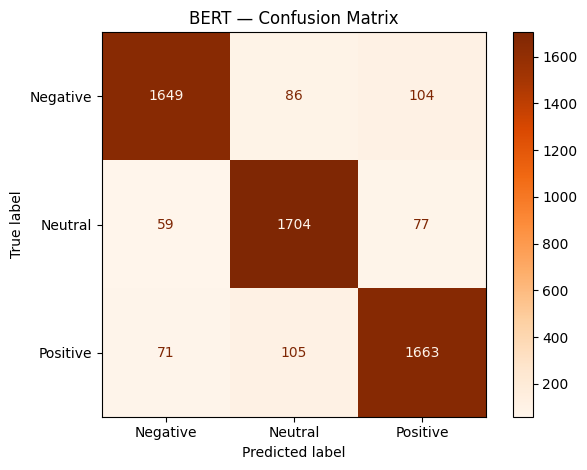

In [ ]:
# Cell 13 — BERT Evaluation
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

bert_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch, labels in test_loader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_model(**batch)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds   = probs.argmax(axis=1)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("--- BERT (Test) ---")
print(f"Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 (macro): {f1_score(all_labels, all_preds, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_bin, all_probs, multi_class='ovr'):.4f}")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds),
                       display_labels=le.classes_).plot(cmap='Oranges')
plt.title('BERT — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 14 — Final Comparison Table
import pandas as pd

y_pred_lr_test = best_lr.predict(X_test)
y_pred_rf_test = best_rf.predict(X_test)
lr_proba       = best_lr.predict_proba(X_test)
rf_proba       = best_rf.predict_proba(X_test)

final_results = {
    'Model':    ['Baseline', 'Logistic Regression', 'Random Forest',
                 'BiLSTM', 'BERT'],
    'Accuracy': [
        round(accuracy_score(y_test, dummy.predict(X_test)), 4),
        round(accuracy_score(y_test, y_pred_lr_test), 4),
        round(accuracy_score(y_test, y_pred_rf_test), 4),
        round(accuracy_score(y_test, y_pred_bilstm), 4),
        round(accuracy_score(all_labels, all_preds), 4)
    ],
    'F1 Macro': [
        round(f1_score(y_test, dummy.predict(X_test), average='macro'), 4),
        round(f1_score(y_test, y_pred_lr_test, average='macro'), 4),
        round(f1_score(y_test, y_pred_rf_test, average='macro'), 4),
        round(f1_score(y_test, y_pred_bilstm, average='macro'), 4),
        round(f1_score(all_labels, all_preds, average='macro'), 4)
    ],
    'ROC-AUC':  [
        'N/A',
        round(roc_auc_score(y_test_bin, lr_proba, multi_class='ovr'), 4),
        round(roc_auc_score(y_test_bin, rf_proba, multi_class='ovr'), 4),
        round(roc_auc_score(y_test_bin, y_proba_bilstm, multi_class='ovr'), 4),
        round(roc_auc_score(y_test_bin, all_probs, multi_class='ovr'), 4)
    ]
}

final_df = pd.DataFrame(final_results)
print("=" * 60)
print("FINAL MODEL COMPARISON ON TEST SET")
print("=" * 60)
print(final_df.to_string(index=False))
print("=" * 60)
print(f"Best Accuracy : {final_df['Accuracy'].max()} ({final_df.loc[final_df['Accuracy'].idxmax(), 'Model']})")
print(f"Best F1 Macro : {final_df['F1 Macro'].max()} ({final_df.loc[final_df['F1 Macro'].idxmax(), 'Model']})")

FINAL MODEL COMPARISON ON TEST SET
              Model  Accuracy  F1 Macro ROC-AUC
           Baseline    0.3333    0.1666     N/A
Logistic Regression    0.8550    0.8552  0.9624
      Random Forest    0.7601    0.7608  0.9188
             BiLSTM    0.8679    0.8679  0.9679
               BERT    0.9090    0.9090  0.9822
Best Accuracy : 0.909 (BERT)
Best F1 Macro : 0.909 (BERT)
